# REINFORCE: Monte-Carlo Control with Policy Approximation

## Installation and Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* `gym-classics2` (see [Installation instructions](../common/Setup_gym_classics2.ipynb))

In [9]:
import numpy as np
np.set_printoptions(precision=2)

In [10]:
import gymnasium as gym
import gym_classics2
gym_classics2.register('gymnasium')

/home/mhahsler/github/Introduction_to_Reinforcement_Learning/common/gym-classics/gym_classics2/__init__.py:67: UserWarning: gym-classics environments were already registered for gymnasium; additional calls to `register()` are ignored.
  warnings.warn("gym-classics environments were already registered for {}; "


## Define the L-Maze Grid World 

In [11]:
gym_env = gym.make('LMaze-v0', tabular = False)
env = gym_env.unwrapped

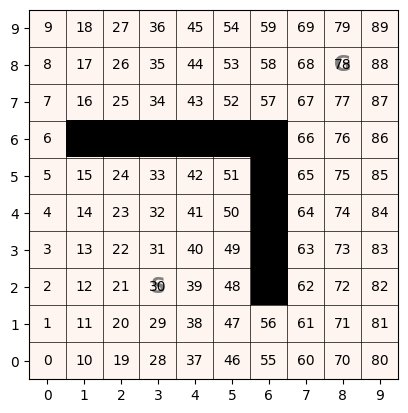

In [12]:
env.image()

## Policy Approximation: Linear Soft-Max In Action Preferences

Use Fourier-basis transformation and set up state-action features.

In [22]:
from gym_classics2.algorithms.linear_approximation import transformation_fourier_basis, state_features, state_action_features

trans_fb = transformation_fourier_basis(min = np.array([0,0]), max = env.dims, order=2)

def state_features(s,env):
    return trans_fb(s)

gym_classics2.algorithms.linear_approximation.state_features = state_features

Define the preference function $h(s,a,\bf{\theta})=\bf{\theta}^\top \bf{x}(s,a)$

In [23]:
def h(s,a,theta,env):
    return np.dot(theta, state_action_features(s,a,env))

Soft-max transformation from scores to a probability distribution: $\pi(s,a,\theta) = \frac{e^{h(s,a,\bf{\theta})}}{\sum_b h(s,a,\bf{\theta})}$

In [24]:
def pi(s,theta,env):
    hs = np.array([h(s,a,theta,env) for a in range(env.action_space.n)])
    exp_hs = np.exp(hs)
    return exp_hs / np.sum(exp_hs)

Check with a random weight vector.

In [29]:
theta = np.random.rand(len(state_action_features((0, 0), 0, env)))
theta

array([0.16, 0.83, 0.71, 0.96, 0.74, 0.11, 0.96, 0.58, 0.24, 0.1 , 0.15,
       0.44, 0.86, 0.25, 0.68, 0.75, 0.56, 0.08, 0.12, 0.13, 0.01, 0.82,
       0.26, 0.02, 0.36, 0.64, 0.28, 0.76, 0.69, 0.31, 0.03, 0.19, 0.52,
       0.07, 0.  , 0.53, 0.21])

Calculate the preferences score for all actions for state 0.

In [31]:
[h((0, 0),a,theta, env) for a in range(env.action_space.n)] 

[np.float64(5.297810913082818),
 np.float64(3.945834554619414),
 np.float64(1.9601209138042086),
 np.float64(3.5715413481401503)]

Calculate $\pi(s,a,\theta)$ for all actions in state $s=0$

In [32]:
pi((0,0),theta,env)

array([0.68, 0.18, 0.02, 0.12])

## REINFORCE: Monte-Carlo Control

![Pseudocode REINFORCE](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-Intro_REINFORCE.png)

We need to sample following a stochastic policy.

In [33]:
def sample_episode_policy(env, pi, theta, max_episode_length=1000):
    """
    Sample an episode using the policy defined by pi and theta.
    Returns a list of (state, action, reward) tuples.
    """
    s, _ = env.reset()
    episode_data = []
    
    for t in range(max_episode_length):
        a = np.random.choice(range(env.action_space.n), p=pi(s,theta,env))
        next_s, r, done, _, _ = env.step(a)
        episode_data.append((s, a, r, next_s))
        s = next_s
        
        if done:
            break
    
    return episode_data


In [34]:
episode_data = sample_episode_policy(env, pi, theta)
episode_data

[((3, 2), np.int64(3), 0.0, (2, 2)),
 ((2, 2), np.int64(0), 0.0, (2, 3)),
 ((2, 3), np.int64(0), 0.0, (2, 4)),
 ((2, 4), np.int64(3), 0.0, (1, 4)),
 ((1, 4), np.int64(0), 0.0, (1, 5)),
 ((1, 5), np.int64(3), 0.0, (0, 5)),
 ((0, 5), np.int64(3), 0.0, (0, 5)),
 ((0, 5), np.int64(3), 0.0, (0, 5)),
 ((0, 5), np.int64(1), 0.0, (1, 5)),
 ((1, 5), np.int64(1), 0.0, (2, 5)),
 ((2, 5), np.int64(3), 0.0, (1, 5)),
 ((1, 5), np.int64(3), 0.0, (0, 5)),
 ((0, 5), np.int64(0), 0.0, (0, 6)),
 ((0, 6), np.int64(3), 0.0, (0, 6)),
 ((0, 6), np.int64(1), 0.0, (0, 6)),
 ((0, 6), np.int64(1), 0.0, (0, 6)),
 ((0, 6), np.int64(2), 0.0, (0, 5)),
 ((0, 5), np.int64(3), 0.0, (0, 5)),
 ((0, 5), np.int64(0), 0.0, (0, 6)),
 ((0, 6), np.int64(0), 0.0, (0, 7)),
 ((0, 7), np.int64(0), 0.0, (0, 8)),
 ((0, 8), np.int64(2), 0.0, (0, 7)),
 ((0, 7), np.int64(3), 0.0, (0, 7)),
 ((0, 7), np.int64(0), 0.0, (0, 8)),
 ((0, 8), np.int64(2), 0.0, (0, 7)),
 ((0, 7), np.int64(3), 0.0, (0, 7)),
 ((0, 7), np.int64(0), 0.0, (0, 8)),
 

Implement the REINFORCE algorithm. The gradient of the policy for linear approximation is proportional to  $\nabla ln\ \pi(s,a,\bf{\theta}) =   \bf{x}(s,a) - \sum_b \pi(b|s,\bf{\theta}) \bf{x}(s,b)$

In [35]:
from gym_classics2.algorithms.schedules import LinearDecaySchedule, ConstantSchedule
from tqdm import tqdm

def REINFORCE(
    env,
    n,
    alpha,
    gamma,
    theta = None,
    max_episode_length=1000,
    verbose=False,
    history=False
    ):
    
    if theta is None:
        state, _ = env.reset()  
        theta = np.zeros(1 + len(state_features(state, env)) * env.action_space.n)
    
    if history:
        returns = []        
        ep_lens = []
        thetas = []
        thetas.append(theta.copy())
        
    for episode in tqdm(range(n), desc="Episodes", disable=verbose):
        if verbose:
            print(f"Episode {episode+1}/{n}")
        
        episode_data = sample_episode_policy(env, pi, theta, max_episode_length)
        
        for t in range(len(episode_data)):
            G = np.sum([e[2] for e in episode_data[t:]] * (gamma ** np.arange(len(episode_data[t:]))))
            if history and t == 0:
                returns.append(G)   

            s,a,r,next_s = episode_data[t]
            
            # ln policy gradient= x(s,a)- sum_b pi(b|s,theta) x(s,b)
            grad_log_pi = state_action_features(s, a, env) - sum([pi(s, theta, env)[b] * state_action_features(s, b, env) for b in range(env.action_space.n)])
            
            if verbose: 
                print (f"t: {t}, G: {G}, grad_log_pi: {grad_log_pi}")
            
            theta += alpha(episode) * (gamma**t) * G * grad_log_pi
            
        if history:
            thetas.append(theta.copy())
            ep_lens.append(len(episode_data))
            
    if history:
        return theta, {'thetas': thetas, 'returns': returns, 'ep_lens': ep_lens}
       
    return theta

In [36]:
theta, history = REINFORCE(env, n=2000, 
                           alpha=LinearDecaySchedule(0.1, 0.001, 1000),
                           gamma=0.99, 
                           max_episode_length = 500,
                           history=True)

Episodes: 100%|██████████| 2000/2000 [00:34<00:00, 57.23it/s]


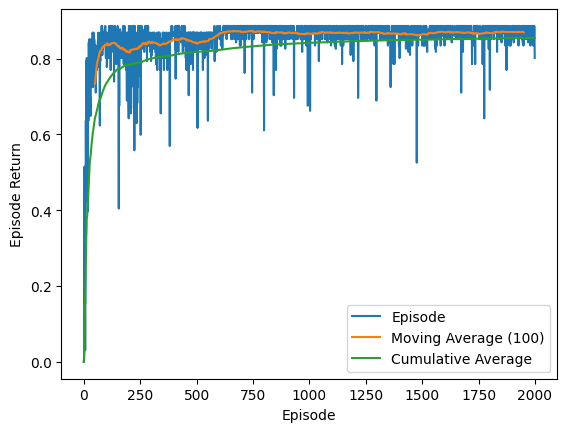

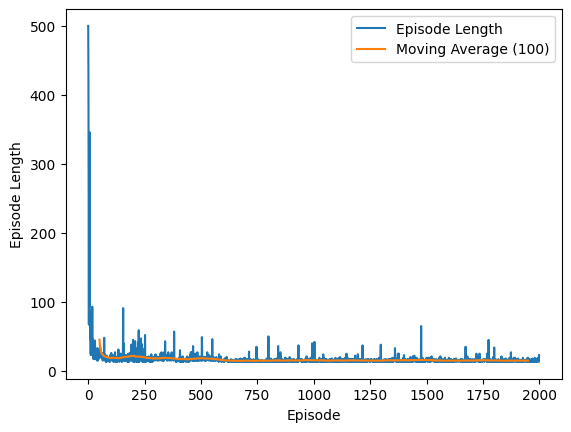

In [37]:
from gym_classics2.performance import plot_returns, plot_ep_lens
plot_returns(history['returns'])
plot_ep_lens(history['ep_lens'])

Note: MC produces initially high variance.

## The Learned Policy

In [38]:
pol = [pi(env.id2state(s), theta,env) for s in env.states()]
pol

[array([2.12e-03, 9.97e-01, 2.31e-05, 5.27e-04]),
 array([4.99e-03, 9.93e-01, 1.20e-04, 1.59e-03]),
 array([0.05, 0.92, 0.01, 0.03]),
 array([0.15, 0.17, 0.44, 0.24]),
 array([0.03, 0.  , 0.86, 0.11]),
 array([7.41e-03, 1.48e-04, 9.27e-01, 6.55e-02]),
 array([6.90e-03, 1.50e-04, 8.95e-01, 9.78e-02]),
 array([0.02, 0.  , 0.7 , 0.28]),
 array([0.04, 0.02, 0.31, 0.63]),
 array([0.05, 0.16, 0.09, 0.7 ]),
 array([8.96e-04, 9.99e-01, 2.56e-05, 2.98e-04]),
 array([1.44e-03, 9.97e-01, 2.81e-04, 8.25e-04]),
 array([0.01, 0.93, 0.04, 0.02]),
 array([0.02, 0.06, 0.84, 0.08]),
 array([4.36e-03, 5.55e-04, 9.58e-01, 3.69e-02]),
 array([3.07e-03, 4.96e-05, 9.51e-01, 4.60e-02]),
 array([0.03, 0.  , 0.52, 0.46]),
 array([0.05, 0.02, 0.18, 0.75]),
 array([0.06, 0.2 , 0.07, 0.67]),
 array([1.04e-04, 1.00e+00, 3.59e-05, 7.12e-05]),
 array([1.79e-04, 9.99e-01, 7.96e-04, 2.37e-04]),
 array([0.  , 0.85, 0.14, 0.01]),
 array([0.  , 0.02, 0.97, 0.01]),
 array([1.27e-03, 1.95e-04, 9.84e-01, 1.47e-02]),
 array([

Visualize the learned policy by showing the action with the highest probability. The probability is shown using the tile color. 
Closer to 1 means that the algorithm is more sure about the action. Smaller values means that the algorithms still would like to explore.

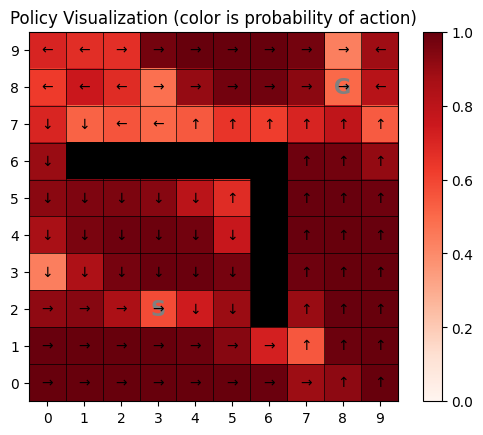

In [42]:
pol_discrete = np.argmax(pol, axis=1)
prob = np.max(pol, axis=1)
env.image(V=prob, policy=pol_discrete, title="Policy Visualization (color is probability of action)",  clim = (0,1))

Visualize the found path using the highest probability action.

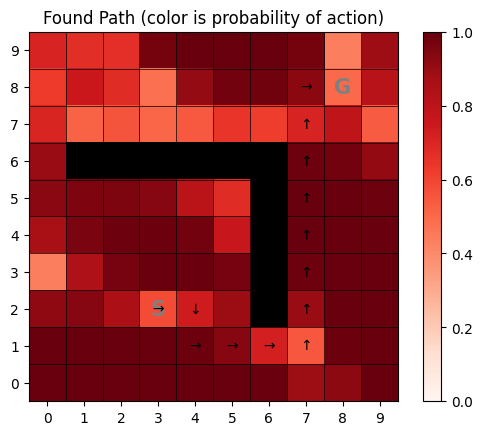

In [41]:
from gym_classics2.algorithms.monte_carlo_methods import sample_episode

path = sample_episode(env, policy=pol_discrete, max_len=100)
path = [(env.state2id(s), a, r,env.state2id(sp)) for s,a,r,sp in path]
env.image(V = prob, policy=pol_discrete, episode=path, title='Found Path (color is probability of action)', clim = (0,1))


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)